# Full-Sweep Diagnostics

Three checks on the full-sweep data before moving to substantive analyses:

- **D1** — null convergence of `Sus(t)` toward zero.
- **D2** — per-round variance calibration (empirical vs theoretical `σ²`).
- **D3** — scaling of `Var[Sus(t)]` with `1/t`.

Figures are saved to `results/full_sweep/analyses/diagnostics/`.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow.dataset as dset


def _find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path().resolve())
    while p != p.parent:
        if (p / 'experiments' / 'full_sweep').exists():
            return p
        p = p.parent
    raise RuntimeError('repo root not found')


ROOT = _find_repo_root()
SWEEP_DIR = ROOT / 'results' / 'full_sweep'
TRAJ_DIR = SWEEP_DIR / 'trajectories'
SIMS_DIR = SWEEP_DIR / 'simulations'
OUT_DIR = SWEEP_DIR / 'analyses' / 'diagnostics'
OUT_DIR.mkdir(parents=True, exist_ok=True)

ALPHA_REPR = [1.0, 3.0, 10.0]

USE_COLS = [
    'cell_id', 'round', 'theta_star', 'psi_true', 'alpha',
    'surp2_score', 'surp2_sigma2', 'surp2_Sus',
    'sus1_score', 'sus1_sigma2_naive', 'sus1_sigma2_corrected', 'sus1_Sus',
]


def load_trajectories(columns=USE_COLS) -> pd.DataFrame:
    ds = dset.dataset(str(TRAJ_DIR), format='parquet', partitioning='hive')
    return ds.to_table(columns=columns).to_pandas()


def alpha_colors(alphas) -> dict:
    ranked = sorted({float(a) for a in alphas})
    cmap = plt.get_cmap('viridis')
    n = max(1, len(ranked) - 1)
    return {a: cmap(i / n) for i, a in enumerate(ranked)}


def save(fig, name: str):
    fig.savefig(OUT_DIR / name, dpi=150, bbox_inches='tight')

## Setup

Load the partitioned trajectory dataset, project only columns needed for D1–D3,
and report shape / axes / memory.

In [2]:
df = load_trajectories()

print(f'rows:          {len(df):,}  (full sweep = 8,910,000)')
print(f'memory:        {df.memory_usage(deep=True).sum() / 1e9:.2f} GB')
print(f'cells present: {df["cell_id"].nunique()} / 297')
print(f'theta_star:    {sorted(df["theta_star"].unique())}')
print(f'psi_true:      {sorted(df["psi_true"].unique())}')
print(f'alpha:         {sorted(df["alpha"].unique())}')
print(f'round range:   {int(df["round"].min())}..{int(df["round"].max())}')

COLORS = alpha_colors(df['alpha'].unique())
null = df[df['psi_true'] == 'inf'].copy()
print(f'null rows:     {len(null):,}')

rows:          8,910,000  (full sweep = 8,910,000)
memory:        1.26 GB
cells present: 297 / 297
theta_star:    [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]
psi_true:      ['inf', 'pers+', 'pers-']
alpha:         [np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(7.0), np.float64(10.0), np.float64(15.0), np.float64(20.0)]
round range:   1..150
null rows:     2,970,000


## D1 — Null convergence of `Sus(t)`

Under the null (`psi_true = inf`), `Sus(t)` should converge to 0 by `t = 150`.
Expectation: faster convergence at higher `alpha` (speaker more predictable);
noisier at low `alpha`.

In [ ]:
d1 = (null.groupby(['alpha', 'theta_star', 'round'], as_index=False)
          .agg(surp2_Sus=('surp2_Sus', 'mean'),
               sus1_Sus=('sus1_Sus', 'mean')))
d1.head()

,alpha,theta_star,round,surp2_Sus,sus1_Sus
0,1.0,0.1,1,0.097426,-0.059097
1,1.0,0.1,2,0.153028,-0.047043
2,1.0,0.1,3,0.149787,-0.038549
3,1.0,0.1,4,0.136702,-0.036507
4,1.0,0.1,5,0.126468,-0.038860


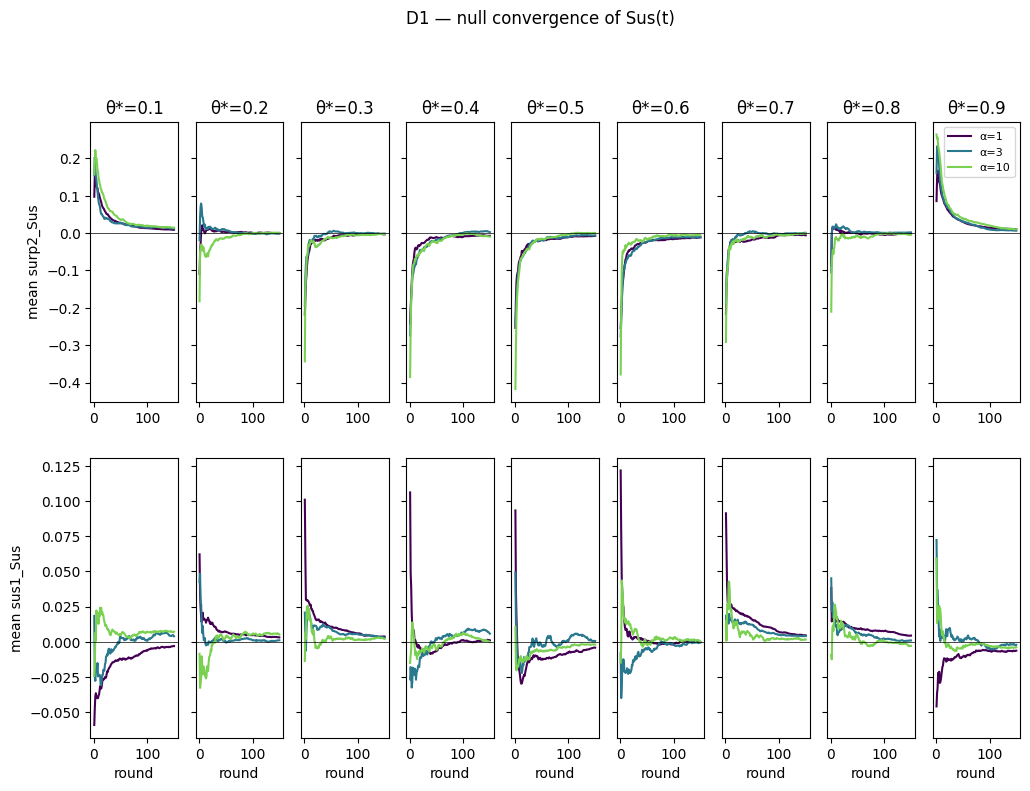

In [4]:
thetas = sorted(d1['theta_star'].unique())
ncol = max(1, len(thetas))
fig, axes = plt.subplots(2, ncol, figsize=(12, 8), sharey='row', squeeze=False)
for j, th in enumerate(thetas):
    sub = d1[d1['theta_star'] == th]
    for a in ALPHA_REPR:
        ss = sub[sub['alpha'] == a]
        axes[0, j].plot(ss['round'], ss['surp2_Sus'],
                        color=COLORS[a], label=f'α={a:g}')
        axes[1, j].plot(ss['round'], ss['sus1_Sus'],
                        color=COLORS[a], label=f'α={a:g}')
    axes[0, j].axhline(0, color='k', lw=0.5)
    axes[1, j].axhline(0, color='k', lw=0.5)
    axes[0, j].set_title(f'θ*={th:g}')
    axes[1, j].set_xlabel('round')
axes[0, 0].set_ylabel('mean surp2_Sus')
axes[1, 0].set_ylabel('mean sus1_Sus')
axes[0, -1].legend(fontsize=8, loc='best')
fig.suptitle('D1 — null convergence of Sus(t)', y=1.02)
save(fig, 'D1_null_convergence.png')
plt.show()

**D1 observations**

- Does `Sus(t)` approach zero by t=150? *(fill in after inspection)*
- Rate of convergence vs `alpha`? Expected faster at higher `alpha`.
- Any `theta_star` noticeably worse?

## D2 — Per-round variance calibration

For each `(alpha, round)` under the null, compare empirical variance of the
score (pooled across sims and `theta*`) to the mean theoretical `σ²`. Ratios
should be ≈ 1 for a well-calibrated variance formula.

Expected from Group 1 + sus-variants:
- `surp2`: ratio ≈ 1.
- `sus1 naive`: ratio ≈ 0.88.
- `sus1 corrected`: ratio ≈ 0.99.

In [5]:
def calib(df_null: pd.DataFrame, score_col: str, sigma_col: str) -> pd.DataFrame:
    g = df_null.groupby(['alpha', 'round'])
    out = pd.DataFrame({
        'var_emp': g[score_col].var(ddof=0),
        'mean_sigma2': g[sigma_col].mean(),
    }).reset_index()
    out['ratio'] = out['var_emp'] / out['mean_sigma2']
    return out


d2_surp2 = calib(null, 'surp2_score', 'surp2_sigma2')
d2_naive = calib(null, 'sus1_score', 'sus1_sigma2_naive')
d2_corr  = calib(null, 'sus1_score', 'sus1_sigma2_corrected')
d2_surp2.head()

,alpha,round,var_emp,mean_sigma2,ratio
0,1.0,1,0.118822,0.194946,0.609515
1,1.0,2,0.291786,0.303056,0.962813
2,1.0,3,0.294814,0.303422,0.971632
3,1.0,4,0.342197,0.294661,1.161327
4,1.0,5,0.354547,0.289225,1.225851


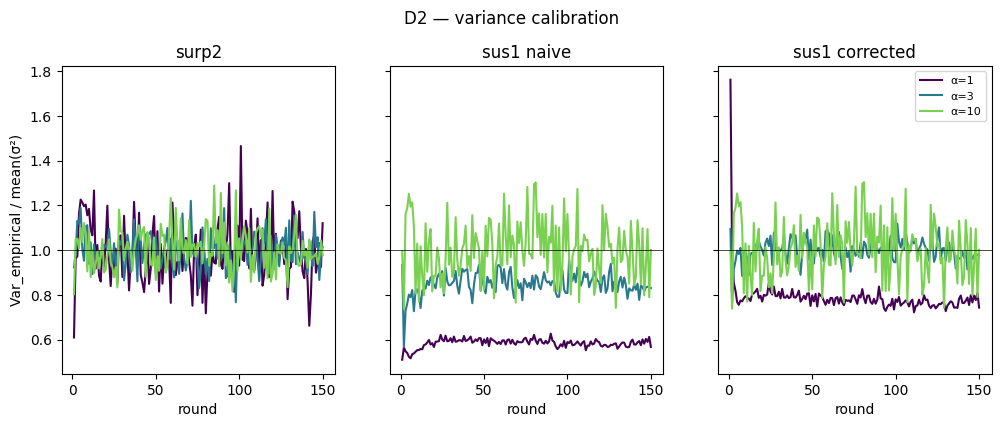

In [6]:
panels = [
    ('surp2', d2_surp2),
    ('sus1 naive', d2_naive),
    ('sus1 corrected', d2_corr),
]
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
for ax, (title, tbl) in zip(axes, panels):
    for a in ALPHA_REPR:
        s = tbl[tbl['alpha'] == a]
        ax.plot(s['round'], s['ratio'], color=COLORS[a], label=f'α={a:g}')
    ax.axhline(1, color='k', lw=0.5)
    ax.set_title(title)
    ax.set_xlabel('round')
axes[0].set_ylabel('Var_empirical / mean(σ²)')
axes[-1].legend(fontsize=8)
fig.suptitle('D2 — variance calibration', y=1.02)
save(fig, 'D2_variance_calibration.png')
plt.show()

**D2 observations**

- Do `surp2` and `sus1 corrected` ratios track 1 across all `alpha`?
- Does `sus1 naive` sit near 0.88 everywhere, or is there alpha dependence?
- Any anomalies at extreme alphas?

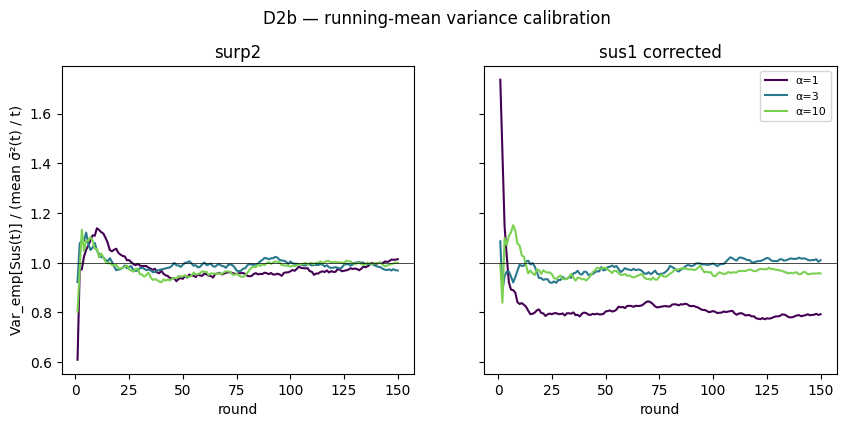

In [9]:
# D2b — running-mean variance calibration
# Under the null: Var[Sus(t)] ≈ E[sigma_bar^2(t)] / t.
# Pool across sims (and theta*) at each (alpha, round).

def calib_running(df_null: pd.DataFrame, sus_col: str, sigma_col: str) -> pd.DataFrame:
    # running mean of per-round sigma^2 within each trajectory
    df_null = df_null.sort_values(['cell_id', 'round']).copy()
    df_null['sigma_bar2'] = (df_null.groupby('cell_id')[sigma_col]
                                    .expanding().mean()
                                    .reset_index(level=0, drop=True))
    g = df_null.groupby(['alpha', 'round'])
    out = pd.DataFrame({
        'var_emp_Sus':       g[sus_col].var(ddof=0),
        'mean_sigma_bar2':   g['sigma_bar2'].mean(),
    }).reset_index()
    out['theory_var_Sus'] = out['mean_sigma_bar2'] / out['round']
    out['ratio'] = out['var_emp_Sus'] / out['theory_var_Sus']
    return out


d2b_surp2 = calib_running(null, 'surp2_Sus', 'surp2_sigma2')
d2b_corr  = calib_running(null, 'sus1_Sus',  'sus1_sigma2_corrected')

panels = [('surp2', d2b_surp2), ('sus1 corrected', d2b_corr)]
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (title, tbl) in zip(axes, panels):
    for a in ALPHA_REPR:
        s = tbl[tbl['alpha'] == a]
        ax.plot(s['round'], s['ratio'], color=COLORS[a], label=f'α={a:g}')
    ax.axhline(1, color='k', lw=0.5)
    ax.set_title(title)
    ax.set_xlabel('round')
axes[0].set_ylabel('Var_emp[Sus(t)] / (mean σ̄²(t) / t)')
axes[-1].legend(fontsize=8)
fig.suptitle('D2b — running-mean variance calibration', y=1.02)
save(fig, 'D2b_running_variance_calibration.png')
plt.show()


## D3 — Running-mean variance scaling

Under the null, `Var[Sus(t)] ∝ 1/t`. Plot empirical running-mean variance on
log-log axes with a slope-(−1) reference line anchored at `t=10`.

In [7]:
def var_running(df_null: pd.DataFrame, col: str) -> pd.DataFrame:
    return (df_null.groupby(['alpha', 'round'])[col]
                   .var(ddof=0)
                   .reset_index(name='var'))


d3_surp2 = var_running(null, 'surp2_Sus')
d3_sus1  = var_running(null, 'sus1_Sus')
d3_surp2.head()

,alpha,round,var
0,1.0,1,0.118822
1,1.0,2,0.110718
2,1.0,3,0.084069
3,1.0,4,0.069394
4,1.0,5,0.058001


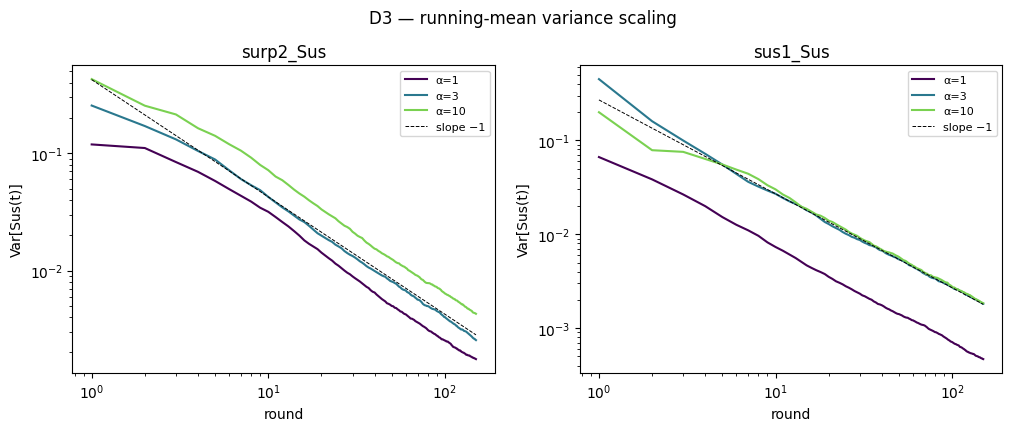

In [8]:
panels = [('surp2_Sus', d3_surp2), ('sus1_Sus', d3_sus1)]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, tbl) in zip(axes, panels):
    for a in ALPHA_REPR:
        s = tbl[tbl['alpha'] == a]
        ax.loglog(s['round'], s['var'], color=COLORS[a], label=f'α={a:g}')
    anchor = tbl[(tbl['alpha'] == ALPHA_REPR[1]) & (tbl['round'] == 10)]
    if len(anchor):
        C = float(anchor['var'].iloc[0]) * 10
        ts = np.logspace(0, np.log10(150), 50)
        ax.loglog(ts, C / ts, 'k--', lw=0.7, label='slope −1')
    ax.set_title(title)
    ax.set_xlabel('round')
    ax.set_ylabel('Var[Sus(t)]')
    ax.legend(fontsize=8)
fig.suptitle('D3 — running-mean variance scaling', y=1.02)
save(fig, 'D3_running_variance_scaling.png')
plt.show()

**D3 observations**

- Do the curves track slope −1 on log-log?
- Deviations at low `alpha`? (Would signal auto-correlation inflating running variance.)
- Is scaling the same for `surp2_Sus` and `sus1_Sus`?

## Summary

| Check | Pass / Fail | Notes |
|-------|-------------|-------|
| D1 — null convergence       |  |  |
| D2 — variance calibration   |  |  |
| D3 — running-var scaling    |  |  |

Confident to proceed to substantive analyses: **yes / no**.

## D4 — Null-convergence deep-dive (α=1, longer rounds)

Higher-resolution view of null convergence at the lowest α (where mixing is slowest and asymptotic behavior takes longest to set in). Loads from `results/full_sweep/null_convergence/` if present — produced by:

```
python experiments/full_sweep/run_sweep.py     --out_dir results/full_sweep/null_convergence     --only_psi inf --only_alpha 1.0     --n_sims 500 --rounds 500
```

Three subchecks:
- **D4a** — pooled `Sus(t)` mean ± CI vs round (per θ*).
- **D4b** — `√t · Sus(t)` should look stationary if `Var[Sus(t)] ∝ 1/t` and the mean → 0.
- **D4c** — empirical `Var[Sus(t)] · t` vs round (should flatten at the asymptotic noise floor).


In [ ]:
NULL_DIR = SWEEP_DIR / 'null_convergence'
NULL_TRAJ = NULL_DIR / 'trajectories'

if not NULL_TRAJ.exists():
    print(f'no data at {NULL_TRAJ}
'
          'run experiments/full_sweep/run_sweep.py with '
          '--out_dir results/full_sweep/null_convergence '
          '--only_psi inf --only_alpha 1.0 --n_sims 500 --rounds 500')
    nc = None
else:
    cols = ['cell_id', 'sim_id', 'round', 'theta_star', 'alpha',
            'surp2_score', 'surp2_sigma2', 'surp2_Sus',
            'sus1_score', 'sus1_sigma2_corrected', 'sus1_Sus']
    nc = (dset.dataset(str(NULL_TRAJ), format='parquet', partitioning='hive')
              .to_table(columns=cols).to_pandas())
    print(f'rows:        {len(nc):,}')
    print(f'cells:       {nc["cell_id"].nunique()}')
    print(f'theta_star:  {sorted(nc["theta_star"].unique())}')
    print(f'sims/cell:   {nc.groupby("cell_id")["sim_id"].nunique().unique().tolist()}')
    print(f'round range: {int(nc["round"].min())}..{int(nc["round"].max())}')


### D4a — Pooled `Sus(t)` mean with CI

Mean across sims at each round, with ±1.96·SE band. Plotted per θ* on a shared y-axis. The band should shrink ∝ 1/√t and the mean should hug zero.

In [ ]:
def _mean_ci(g, col):
    n = g[col].count()
    m = g[col].mean()
    sd = g[col].std(ddof=1)
    se = sd / np.sqrt(n)
    return pd.Series({'mean': m, 'lo': m - 1.96 * se, 'hi': m + 1.96 * se, 'n': n})

if nc is not None:
    thetas = sorted(nc['theta_star'].unique())
    fig, axes = plt.subplots(2, len(thetas), figsize=(2.0 * len(thetas), 6),
                             sharex=True, sharey='row', squeeze=False)
    for j, th in enumerate(thetas):
        sub = nc[nc['theta_star'] == th]
        for row, score in enumerate(['surp2_Sus', 'sus1_Sus']):
            stats = (sub.groupby('round').apply(lambda g: _mean_ci(g, score))
                        .reset_index())
            ax = axes[row, j]
            ax.fill_between(stats['round'], stats['lo'], stats['hi'],
                            color='C0', alpha=0.25, lw=0)
            ax.plot(stats['round'], stats['mean'], color='C0', lw=1)
            ax.axhline(0, color='k', lw=0.5)
            if row == 0:
                ax.set_title(f'θ*={th:g}', fontsize=9)
            if row == 1:
                ax.set_xlabel('round')
    axes[0, 0].set_ylabel('surp2_Sus  mean ±95% CI')
    axes[1, 0].set_ylabel('sus1_Sus  mean ±95% CI')
    fig.suptitle('D4a — null convergence (α=1)  per θ*', y=1.01)
    fig.tight_layout()
    save(fig, 'D4a_null_convergence_alpha1.png')
    plt.show()


### D4b — `√t · Sus(t)` stationarity

If `Sus(t)` is asymptotically zero-mean with `Var ∝ 1/t`, then `√t · Sus(t)` should be roughly stationary (constant variance, mean → 0). Drift in this quantity flags either non-zero asymptotic bias or a variance not scaling like 1/t.

In [ ]:
if nc is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
    for ax, score in zip(axes, ['surp2_Sus', 'sus1_Sus']):
        thetas = sorted(nc['theta_star'].unique())
        cmap = plt.get_cmap('viridis')
        for k, th in enumerate(thetas):
            sub = nc[nc['theta_star'] == th]
            stats = (sub.groupby('round')[score]
                        .agg(['mean', 'std', 'count']).reset_index())
            scaled_mean = np.sqrt(stats['round']) * stats['mean']
            scaled_se = (np.sqrt(stats['round']) * stats['std']
                         / np.sqrt(stats['count']))
            color = cmap(k / max(1, len(thetas) - 1))
            ax.plot(stats['round'], scaled_mean, color=color, lw=0.9,
                    label=f'θ*={th:g}')
            ax.fill_between(stats['round'],
                            scaled_mean - 1.96 * scaled_se,
                            scaled_mean + 1.96 * scaled_se,
                            color=color, alpha=0.10, lw=0)
        ax.axhline(0, color='k', lw=0.5)
        ax.set_title(f'√t · mean[{score}]')
        ax.set_xlabel('round')
    axes[0].legend(fontsize=7, ncol=2, loc='upper right')
    fig.suptitle('D4b — √t · Sus(t)  (should be stationary if mean→0, Var∝1/t)',
                 y=1.02)
    fig.tight_layout()
    save(fig, 'D4b_sqrt_t_Sus.png')
    plt.show()


### D4c — `t · Var[Sus(t)]` vs round

Empirical `t · Var[Sus(t)]` should flatten at the asymptotic per-round score variance once mixing completes. Slope, plateau height, and time-to-plateau are all informative.

In [ ]:
if nc is not None:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
    thetas = sorted(nc['theta_star'].unique())
    cmap = plt.get_cmap('viridis')
    for ax, score in zip(axes, ['surp2_Sus', 'sus1_Sus']):
        for k, th in enumerate(thetas):
            sub = nc[nc['theta_star'] == th]
            v = sub.groupby('round')[score].var(ddof=0).reset_index(name='var')
            color = cmap(k / max(1, len(thetas) - 1))
            ax.plot(v['round'], v['round'] * v['var'], color=color, lw=0.9,
                    label=f'θ*={th:g}')
        ax.set_title(f't · Var[{score}]')
        ax.set_xlabel('round')
        ax.set_xscale('log')
    axes[0].legend(fontsize=7, ncol=2, loc='best')
    fig.suptitle('D4c — t · Var[Sus(t)]  (asymptotic plateau = noise floor)',
                 y=1.02)
    fig.tight_layout()
    save(fig, 'D4c_t_var_Sus.png')
    plt.show()


**D4 observations**

- D4a: by what round does the CI cover 0 stably? Any θ* with persistent bias?
- D4b: does √t·Sus(t) flatten, or drift?
- D4c: where does t·Var plateau, and is the plateau θ*-dependent?
